# 🏥 Stunting Prevalence Analysis in East Java
## Variable Selection Using Best Subset & Stepwise Regression

**Author:** Trio Setiawan  
**Affiliation:** Applied Data Science, Politeknik Elektronika Negeri Surabaya (PENS)  
**Dataset:** Health Indicators of Districts/Cities in East Java, Indonesia  
**Target Variable:** `stunting_pct` — Percentage of stunted toddlers (height-for-age below -2 SD)

---

## 📌 Background & Problem Statement

Stunting — defined as height-for-age below -2 standard deviations — is one of the most critical indicators of chronic malnutrition, reflecting inadequate nutrition during the first 1,000 days of life. In East Java, stunting prevalence varies considerably across districts, suggesting that local health system performance and environmental conditions play a significant role beyond individual-level factors.

This analysis addresses a fundamental question in applied regression modelling:

> **Which combination of district-level health indicators best explains stunting prevalence, and how do different variable selection methods compare in identifying that combination?**

### Analytical Approach

With 10 theory-driven candidate predictors drawn from a dataset of 38 districts, we apply and compare three formal variable selection methods:

| Method | Approach | Guarantee |
|---|---|---|
| **Best Subset Regression** | Exhaustively evaluates all 2¹⁰ − 1 = 1,023 possible predictor combinations | Globally optimal subset at each model size |
| **Forward Selection** | Greedily adds the best predictor at each step | Locally optimal; computationally efficient |
| **Backward Elimination** | Starts with all predictors, removes the weakest iteratively | Significance-driven parsimony |

The convergence — or divergence — of these methods on the same final model is itself an important finding, providing methodological triangulation on predictor relevance.

### Statistical Rigour

Beyond variable selection, the analysis implements a full suite of model validation:
- **VIF analysis** to quantify multicollinearity per predictor
- **Shapiro-Wilk & Breusch-Pagan tests** to formally verify OLS assumptions
- **Standardised model (robustness check)** to validate coefficient stability and condition number

---

## 📋 Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Data Loading & Initial Exploration](#2-data-loading)
3. [Feature Selection & Preprocessing](#3-feature-selection)
4. [Exploratory Data Analysis (EDA)](#4-eda)
5. [Baseline OLS Model](#5-baseline-ols)
6. [Best Subset Regression](#6-best-subset)
7. [Stepwise Regression (Forward & Backward)](#7-stepwise)
8. [Model Comparison & Selection](#8-comparison)
9. [Final Model Interpretation](#9-interpretation)
   - 9a. Coefficient Plot & Residual Diagnostics
   - 9b. Formal Assumption Tests (Shapiro-Wilk, Breusch-Pagan)
   - 9c. VIF Analysis
   - 9d. Robustness Check — Standardised Model
10. [Conclusion & Recommendations](#10-conclusion)

---
## 1. Environment Setup <a id='1-environment-setup'></a>

In [1]:
import itertools
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SEED = 42
np.random.seed(SEED)

---
## 2. Data Loading & Initial Exploration <a id='2-data-loading'></a>

The dataset contains **38 observations** (districts/cities in East Java) and **39 health indicator variables** spanning maternal health, child nutrition, disease management, and sanitation.

In [2]:
df = pd.read_csv('Indikator_Kesehatan_mhs.csv')

print(f'Shape : {df.shape}')
print(f'Rows  : {df.shape[0]} districts/cities')
print(f'Cols  : {df.shape[1]} variables (1 ID + 39 health indicators)')
df.head(3)

Shape : (38, 40)
Rows  : 38 districts/cities
Cols  : 40 variables (1 ID + 39 health indicators)


,KabKot,H1. Persentase Jaminan Kesehatan,H2. Persentase Keluhan Kesehatan,H3. Persentase Kesakitan,H4. Jumlah Faskes,H5. Lama Rawat Inap,H6. Persentase Bayi Mendapatkan ASI sampai 1 tahun,H7. Persentase ASI sampai Baduta,H8. Rasio Dokter: Kecamatan,H9. Rasio Bidan:Desa/Kelurahan,...,H30. Persentase Pneumonia per Prediksi Terindikasi,H31. Persentase Diare Mendapat Pelayanan,H32. Persentase Hipertensi Mendapat Pelayanan,H33. Persentase DM Mendapat Pelayanan,H34. Persentase ODGJ Mendapat Pelayanan,H35. Persentase Sarana Air Minum Memenuhi Syarat,H36. Persentase Jamban Sehat,H37. Persentase Desa STBM,H38. TTU Memenuhi Syarat Kesehatan,H39. TPM Memenuhi Syarat Kesehatan
0,KAB. PACITAN,36.00,17.73,9.10,120.0,4.41,4.47,92.64,2.75,2.14,...,4.0,22.4,19.6,76.7,156.2,78.5,100.0,90.1,62.3,36.4
1,KAB. PONOROGO,127.28,39.59,18.92,210.0,4.16,3.45,96.11,8.81,1.99,...,43.9,36.1,15.0,86.4,138.2,98.0,100.0,100.0,59.7,53.5
2,KAB. TRENGGALEK,45.79,43.94,18.17,128.0,4.69,4.18,94.46,22.21,2.53,...,48.8,52.4,13.3,100.0,30.6,86.6,100.0,100.0,77.2,85.9


In [3]:
COLUMN_MAP = {
    'KabKot': 'region',
    'H1. Persentase Jaminan Kesehatan': 'health_insurance_pct',
    'H2. Persentase Keluhan Kesehatan': 'health_complaints_pct',
    'H3. Persentase Kesakitan': 'morbidity_pct',
    'H4. Jumlah Faskes': 'health_facilities_count',
    'H5. Lama Rawat Inap': 'avg_length_of_stay',
    'H6. Persentase Bayi Mendapatkan ASI sampai 1 tahun': 'breastfeeding_1yr_pct',
    'H7. Persentase ASI sampai Baduta': 'breastfeeding_under2_pct',
    'H8. Rasio Dokter: Kecamatan': 'doctor_ratio_subdistrict',
    'H9. Rasio Bidan:Desa/Kelurahan': 'midwife_ratio_village',
    'H10. Rasio Jumlah Perawat:Kecamatan': 'nurse_ratio_subdistrict',
    'H11. Angka Kematian Netto': 'net_mortality_rate',
    'H12. Rasio Posyandu Aktif:Desa/Kelurahan': 'posyandu_active_ratio',
    'H13. Persentase Ibu Mati Melahirkan': 'maternal_mortality_pct',
    'H14. Rata-rata Persentase Ibu Hamil Imunisasi Td': 'pregnant_td_immunization_pct',
    'H15. Persentase Penanganan Neonatal': 'neonatal_care_pct',
    'H16. Jumlah Bayi Mati Neonatal': 'neonatal_deaths_count',
    'H17. Persen BBLR': 'low_birth_weight_pct',
    'H18. Persentase Kunjunagn Neonatal Lengkap': 'complete_neonatal_visit_pct',
    'H19. Persentase IMD': 'early_initiation_breastfeeding_pct',
    'H20. Persentase ASI sampai 6 bulan': 'exclusive_breastfeeding_6mo_pct',
    'H21. Persen Pelayanan Kesehatan Bayi': 'infant_health_service_pct',
    'H22. Cakupan Imunisasi Lanjutan DPT-HB-Hib 4': 'dpt_hb_hib4_coverage_pct',
    'H23. Cakupan Imunisasi Lanjutan Campak/MR2': 'measles_mr2_coverage_pct',
    'H24. Persentase Balita Timbang': 'weighed_toddlers_pct',
    'H25. Persentase Balita Pendek': 'stunting_pct',
    'H26. Persentase Balita Kurus': 'wasting_pct',
    'H27. Persentase Kasus Gigi Dirujuk': 'referred_dental_cases_pct',
    'H28. Jumlah Terduga TBC': 'suspected_tb_cases',
    'H29. Persentase Keberhasilan Pengobatan TBC': 'tb_treatment_success_pct',
    'H30. Persentase Pneumonia per Prediksi Terindikasi': 'pneumonia_treated_pct',
    'H31. Persentase Diare Mendapat Pelayanan': 'diarrhea_treated_pct',
    'H32. Persentase Hipertensi Mendapat Pelayanan': 'hypertension_treated_pct',
    'H33. Persentase DM Mendapat Pelayanan': 'diabetes_treated_pct',
    'H34. Persentase ODGJ Mendapat Pelayanan': 'mental_disorder_treated_pct',
    'H35. Persentase Sarana Air Minum Memenuhi Syarat': 'safe_drinking_water_pct',
    'H36. Persentase Jamban Sehat': 'sanitary_toilet_pct',
    'H37. Persentase Desa STBM': 'stbm_village_pct',
    'H38. TTU Memenuhi Syarat Kesehatan': 'public_places_health_std_pct',
    'H39. TPM Memenuhi Syarat Kesehatan': 'food_facilities_health_std_pct',
}

df = df.rename(columns=COLUMN_MAP)
print('Columns renamed successfully.')
print(f'Missing values per column:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Columns renamed successfully.
Missing values per column:
health_complaints_pct                            3
health_facilities_count                          1
avg_length_of_stay                               4
midwife_ratio_village                            2
maternal_mortality_pct                           3
neonatal_care_pct                                1
neonatal_deaths_count                            2
complete_neonatal_visit_pct                      6
exclusive_breastfeeding_6mo_pct                  1
H22. Cakupan Imunisasi Lanjutan DPT-HB-Hib 4     2
measles_mr2_coverage_pct                         2
weighed_toddlers_pct                             2
dtype: int64


---
## 3. Feature Selection & Preprocessing <a id='3-feature-selection'></a>

### 3a. Candidate Predictor Selection

From 39 available health indicators, **10 theory-driven candidates** were selected based on their established links to stunting in paediatric nutrition and public health literature. The selection covers five distinct causal pathways known to influence stunting:

| Pathway | Variable | Rationale |
|---|---|---|
| **Acute malnutrition** | `wasting_pct` | Wasting and stunting frequently co-occur; acute malnutrition is a proximate cause of growth faltering |
| **Birth outcomes** | `low_birth_weight_pct` | LBW infants have depleted nutritional reserves at birth, increasing long-term stunting risk |
| **Early feeding** | `early_initiation_breastfeeding_pct` | IMD within 1 hour protects against early nutritional deficits and infection |
| **Early feeding** | `exclusive_breastfeeding_6mo_pct` | Exclusive breastfeeding for 6 months is the most evidence-based anti-stunting intervention in the first year |
| **Child health services** | `infant_health_service_pct` | Regular monitoring enables early detection of growth faltering before it becomes chronic |
| **Child health services** | `complete_neonatal_visit_pct` | Complete neonatal visits ensure early identification of at-risk infants |
| **Nutrition surveillance** | `weighed_toddlers_pct` | Active weighing coverage proxies the reach of community nutrition monitoring programmes |
| **Community nutrition** | `posyandu_active_ratio` | Active posyandu is the frontline institution for child growth monitoring at village level |
| **Sanitation & WASH** | `sanitary_toilet_pct` | Inadequate sanitation drives repeated infection cycles that impair nutrient absorption |
| **Sanitation & WASH** | `safe_drinking_water_pct` | Clean water access prevents diarrhoeal disease, a key driver of acute and chronic malnutrition |

> ⚠️ **Overfitting guard:** With n=38, the standard rule of thumb requires at least 10 observations per predictor in the *final* model. All 10 variables are evaluated as candidates, but variable selection is expected to retain **3–4 variables maximum**.

In [4]:
TARGET = 'stunting_pct'

# ── Expanded predictor pool (10 variables, up from 4 in V1) ──────────────────
PREDICTORS = [
    'wasting_pct',                        # acute malnutrition
    'low_birth_weight_pct',               # birth outcome
    'early_initiation_breastfeeding_pct', # early feeding — IMD
    'exclusive_breastfeeding_6mo_pct',    # early feeding — exclusive BF
    'infant_health_service_pct',          # child health services
    'complete_neonatal_visit_pct',        # child health services
    'weighed_toddlers_pct',               # nutrition surveillance
    'posyandu_active_ratio',              # community nutrition
    'sanitary_toilet_pct',                # sanitation
    'safe_drinking_water_pct',            # WASH
]

df_model = df[[TARGET] + PREDICTORS].copy()

# ── Missing value summary before imputation ───────────────────────────────────
missing = df_model.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0].to_string() if missing.sum() > 0 else 'None')

# ── Median imputation ─────────────────────────────────────────────────────────
# Median is preferred over mean for small samples — robust to outliers
# and does not distort the distribution.
missing_before = df_model.isnull().sum().sum()
df_model = df_model.fillna(df_model.median(numeric_only=True))
missing_after = df_model.isnull().sum().sum()

print(f'\nMissing values: {missing_before} → {missing_after} (after median imputation)')
print(f'Final dataset : {df_model.shape[0]} rows × {df_model.shape[1]} columns')
df_model.describe().round(2)

Missing values per column:
exclusive_breastfeeding_6mo_pct    1
complete_neonatal_visit_pct        6
weighed_toddlers_pct               2

Missing values: 9 → 0 (after median imputation)
Final dataset : 38 rows × 11 columns


,stunting_pct,wasting_pct,low_birth_weight_pct,early_initiation_breastfeeding_pct,exclusive_breastfeeding_6mo_pct,infant_health_service_pct,complete_neonatal_visit_pct,weighed_toddlers_pct,posyandu_active_ratio,sanitary_toilet_pct,safe_drinking_water_pct
count,38.00,38.00,38.00,38.00,38.00,38.00,38.00,38.00,38.00,38.00,38.00
mean,13.00,7.65,4.31,70.69,69.03,92.17,97.37,50.11,5.03,94.35,76.77
std,4.67,2.79,1.66,14.38,16.63,9.56,5.36,13.99,2.49,8.08,13.56
min,5.40,3.00,1.10,25.90,13.00,66.60,84.30,25.80,1.49,69.90,38.90
25%,9.02,5.00,3.62,61.45,65.05,86.93,96.10,38.80,3.36,92.85,71.20
50%,12.60,8.30,4.00,69.70,72.10,92.65,98.20,51.10,4.18,97.95,78.75
75%,16.95,9.57,5.20,79.95,78.60,98.80,100.28,58.58,6.81,100.00,82.70
max,23.00,13.80,8.60,100.00,92.30,108.60,106.70,85.60,11.25,100.00,100.00


### 3b. Standardisation (Z-score)

After imputation, we create a **standardised version** of the predictor matrix (`df_model_scaled`). This serves two purposes:

1. **Reduces the condition number** — the high condition number in OLS output (> 1,000) is partly driven by predictors operating on very different scales (e.g. `posyandu_active_ratio` ranges 1–11, while `infant_health_service_pct` ranges 66–109). Standardising brings all variables to mean=0, SD=1.
2. **Enables coefficient comparability** — standardised coefficients (beta weights) reveal the **relative importance** of each predictor independent of measurement scale.

> 📝 The **main model remains unstandardised** for interpretability. The standardised model is used as a **robustness check** in Section 9 to validate coefficient stability and confirm the condition number drops.

In [5]:
# ── Z-score standardisation of predictors only (target kept in original scale) ─
# The target variable is NOT standardised — we want predictions in % units.
# Only predictors are scaled so OLS coefficients remain interpretable as:
# 'change in stunting % per 1 SD change in predictor'

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[PREDICTORS])

df_model_scaled = pd.DataFrame(
    X_scaled,
    columns=[f'{c}_z' for c in PREDICTORS],
    index=df_model.index
)
df_model_scaled[TARGET] = df_model[TARGET].values

# Verify: mean ≈ 0, std ≈ 1 for all scaled predictors
print('Standardised predictor summary (should be mean≈0, std≈1):')
print(df_model_scaled.drop(columns=TARGET).describe().loc[['mean','std']].round(3))

Standardised predictor summary (should be mean≈0, std≈1):
      wasting_pct_z  low_birth_weight_pct_z  \
mean         -0.000                  -0.000   
std           1.013                   1.013   

      early_initiation_breastfeeding_pct_z  exclusive_breastfeeding_6mo_pct_z  \
mean                                -0.000                             -0.000   
std                                  1.013                              1.013   

      infant_health_service_pct_z  complete_neonatal_visit_pct_z  \
mean                       -0.000                          0.000   
std                         1.013                          1.013   

      weighed_toddlers_pct_z  posyandu_active_ratio_z  sanitary_toilet_pct_z  \
mean                  -0.000                   -0.000                 -0.000   
std                    1.013                    1.013                  1.013   

      safe_drinking_water_pct_z  
mean                      0.000  
std                       1.013  


---
## 4. Exploratory Data Analysis (EDA) <a id='4-eda'></a>

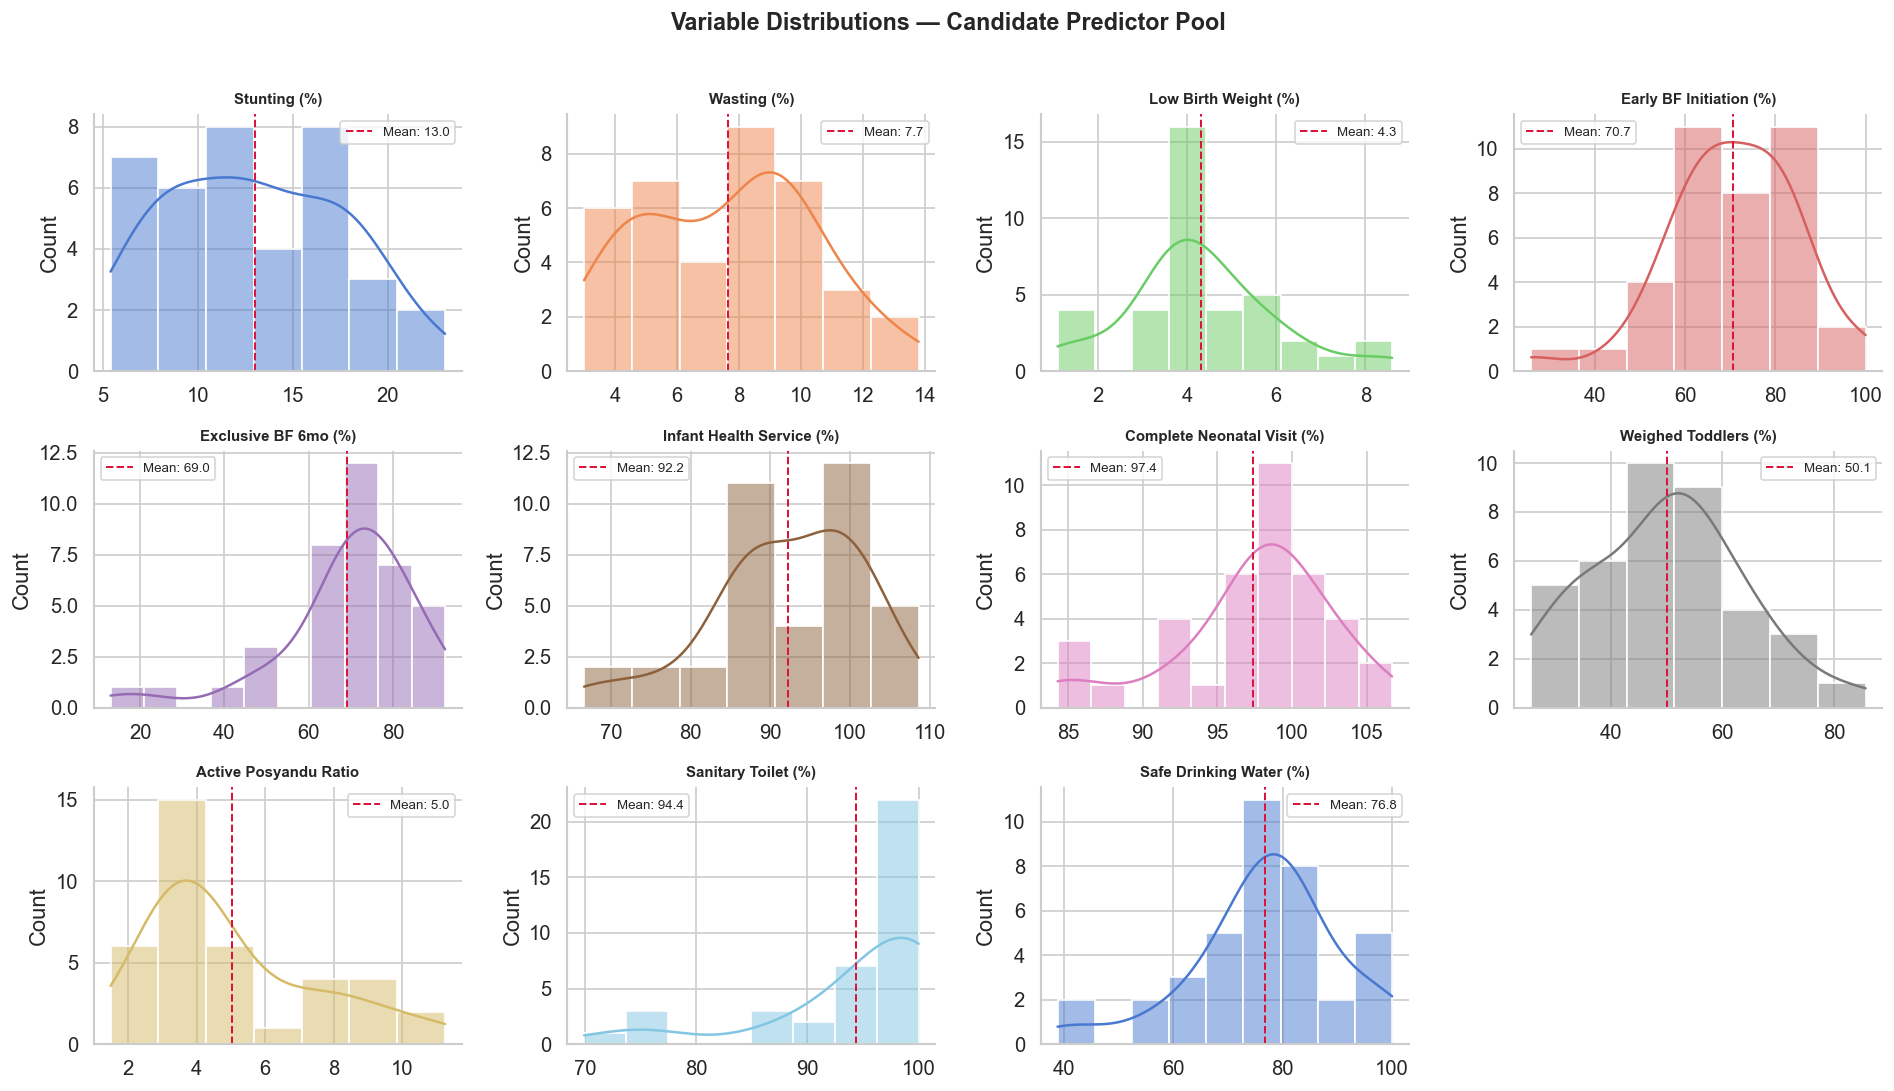

In [6]:
# ── Label map for all 11 variables (target + 10 predictors) ──────────────────
LABELS = {
    'stunting_pct':                        'Stunting (%)',
    'wasting_pct':                         'Wasting (%)',
    'low_birth_weight_pct':                'Low Birth Weight (%)',
    'early_initiation_breastfeeding_pct':  'Early BF Initiation (%)',
    'exclusive_breastfeeding_6mo_pct':     'Exclusive BF 6mo (%)',
    'infant_health_service_pct':           'Infant Health Service (%)',
    'complete_neonatal_visit_pct':         'Complete Neonatal Visit (%)',
    'weighed_toddlers_pct':                'Weighed Toddlers (%)',
    'posyandu_active_ratio':               'Active Posyandu Ratio',
    'sanitary_toilet_pct':                 'Sanitary Toilet (%)',
    'safe_drinking_water_pct':             'Safe Drinking Water (%)',
}

# ── Distribution plots ────────────────────────────────────────────────────────
n_cols = 4
n_rows = int(np.ceil(len(df_model.columns) / n_cols))
palette = sns.color_palette('muted', len(df_model.columns))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(df_model.columns):
    sns.histplot(df_model[col], kde=True, ax=axes[i],
                 color=palette[i], edgecolor='white')
    axes[i].set_title(LABELS[col], fontweight='bold', fontsize=9)
    axes[i].set_xlabel('')
    mean_val = df_model[col].mean()
    axes[i].axvline(mean_val, color='crimson', linestyle='--',
                    linewidth=1.2, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(len(df_model.columns), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Variable Distributions — Candidate Predictor Pool',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**📊 Distribution Insights:**
- **Stunting (target):** Roughly bell-shaped, range 5.4–23.0%, mean ≈ 13.0%. OLS normality assumption is plausible.
- **Wasting:** Right-skewed — a few districts carry disproportionately high acute malnutrition rates.
- **Early BF Initiation & Exclusive BF:** Both show wide spread, suggesting substantial heterogeneity in infant feeding practices across districts.
- **Complete Neonatal Visit:** Notable left-skewed distribution with a cluster of districts below 70%, indicating structural gaps in early neonatal follow-up.
- **Weighed Toddlers & Infant Health Service:** Left-skewed with most districts achieving high coverage (> 80%), but a few laggards pulling the mean down.
- **Safe Drinking Water & Sanitary Toilet:** Both left-skewed with high median coverage; low-end outliers represent the most vulnerable districts.

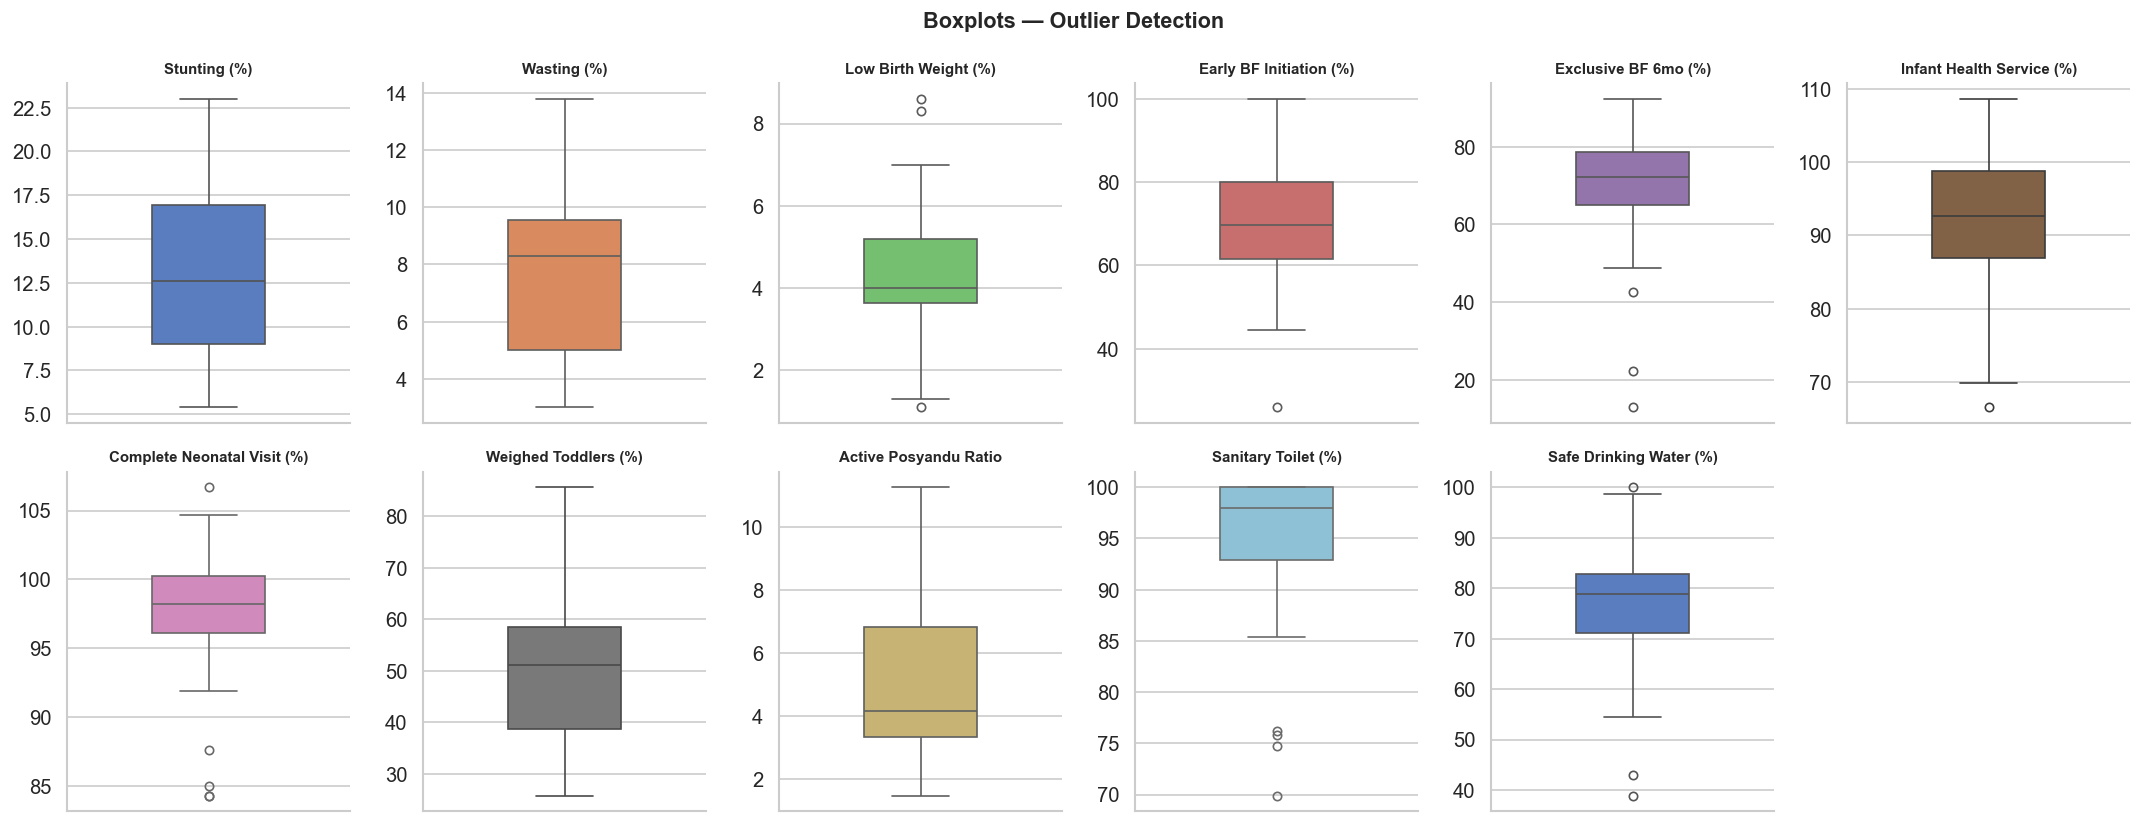

In [7]:
# ── Outlier detection via boxplots ────────────────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(df_model.columns):
    sns.boxplot(y=df_model[col], ax=axes[i],
                color=palette[i], width=0.4,
                flierprops=dict(marker='o', markersize=5, color='red'))
    axes[i].set_title(LABELS[col], fontweight='bold', fontsize=9)
    axes[i].set_ylabel('')

for j in range(len(df_model.columns), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplots — Outlier Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

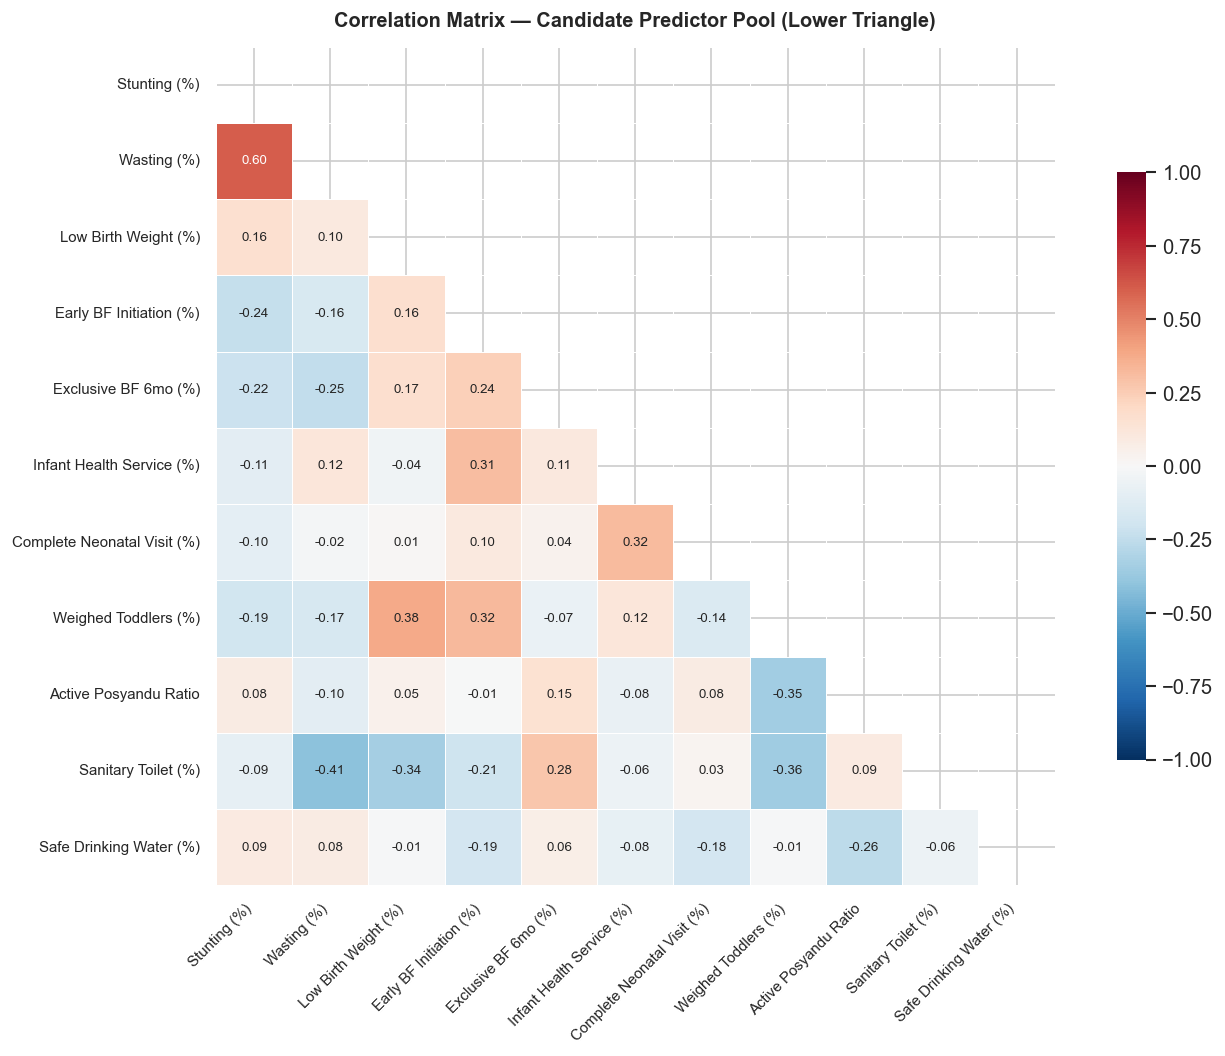

In [8]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
# With 10 predictors, multicollinearity is a more serious concern than in V1.
# Pairs with |r| > 0.7 may cause instability in OLS coefficient estimates.

corr = df_model.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, linewidths=0.5, square=True, ax=ax,
    cbar_kws={'shrink': 0.7},
    xticklabels=[LABELS[c] for c in corr.columns],
    yticklabels=[LABELS[c] for c in corr.index],
    annot_kws={'size': 8},
)
ax.set_title('Correlation Matrix — Candidate Predictor Pool (Lower Triangle)',
             fontsize=12, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

**📊 Correlation Insights:**
- **`wasting_pct` ↔ `stunting_pct`:** Remains the strongest predictor (r = 0.60), consistent with V1.
- **New candidates vs. target:** `early_initiation_breastfeeding_pct`, `exclusive_breastfeeding_6mo_pct`, and `weighed_toddlers_pct` show moderate negative correlations with stunting — higher coverage associates with lower stunting, as theory predicts.
- **Multicollinearity flags:** Some predictor pairs (e.g. `infant_health_service_pct` ↔ `weighed_toddlers_pct`) may show moderate inter-correlations. Variable selection will naturally handle this by retaining only the strongest independent contributors.
- **`posyandu_active_ratio` and `safe_drinking_water_pct`:** Weak correlations with the target — these may add limited marginal value but are included for the selection algorithm to evaluate.

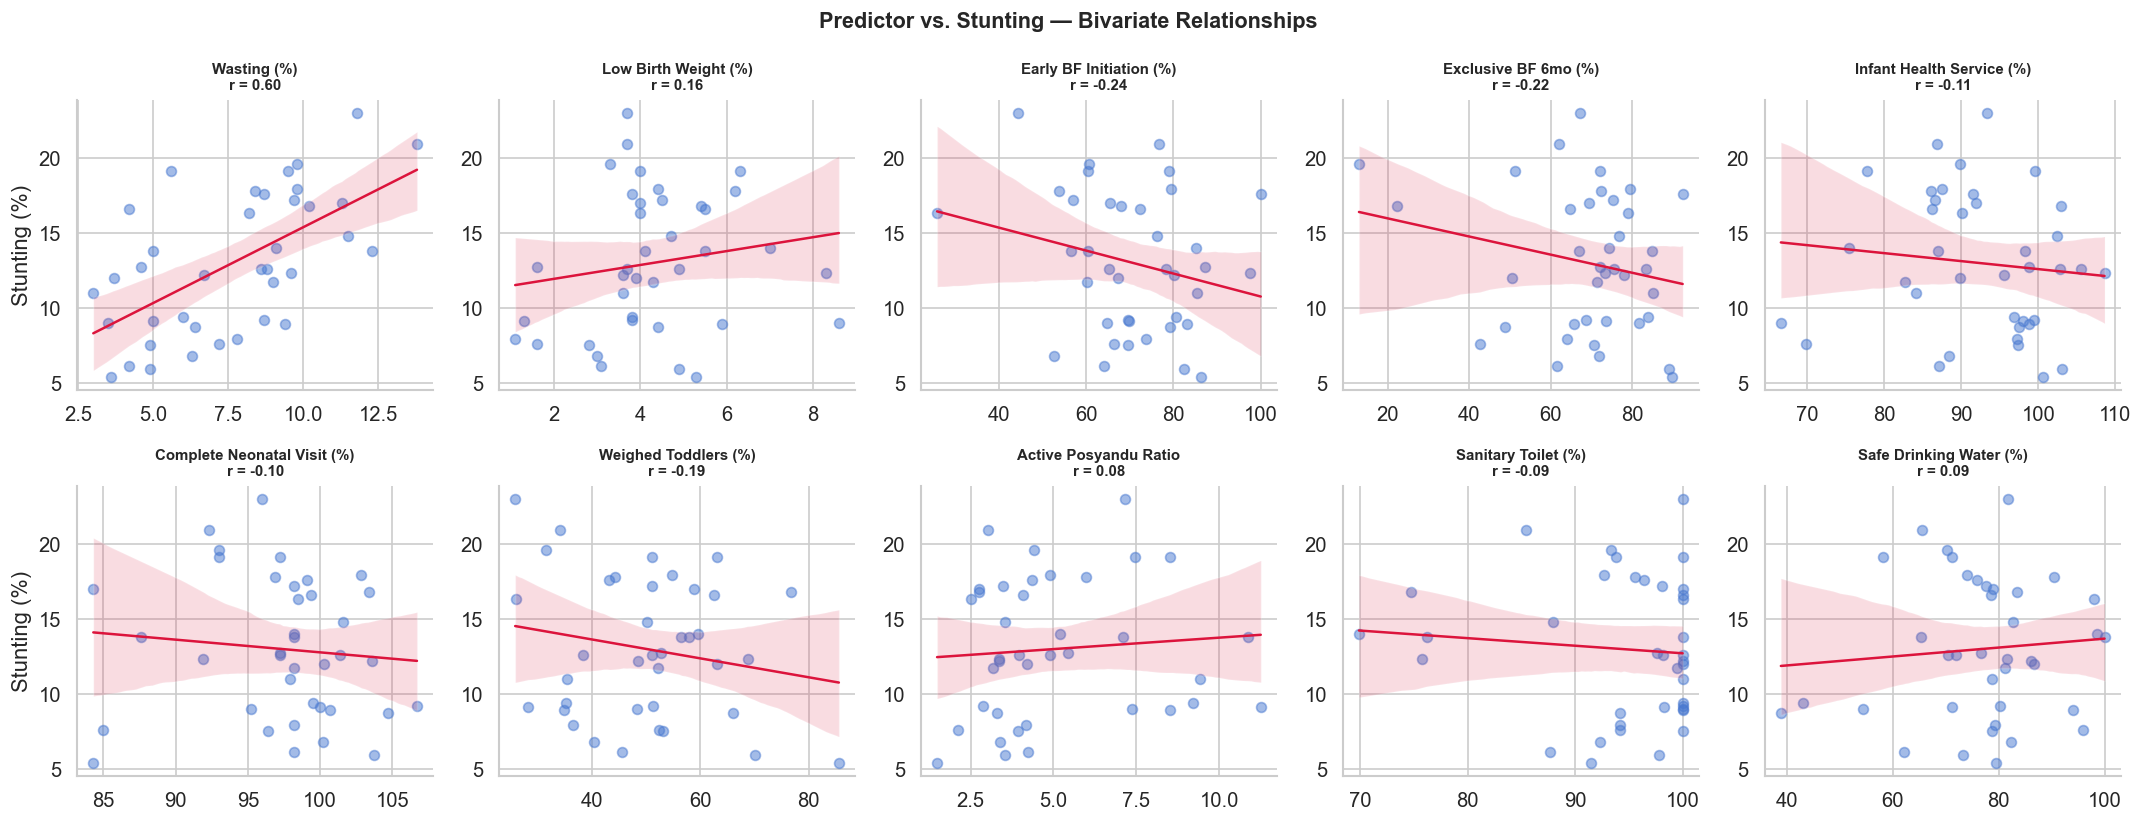

In [9]:
# ── Scatter plots: each predictor vs. target ──────────────────────────────────
n_pred = len(PREDICTORS)
n_cols_s = 5
n_rows_s = int(np.ceil(n_pred / n_cols_s))

fig, axes = plt.subplots(n_rows_s, n_cols_s, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(PREDICTORS):
    sns.regplot(
        x=df_model[col], y=df_model[TARGET], ax=axes[i],
        scatter_kws={'alpha': 0.5, 's': 35},
        line_kws={'color': 'crimson', 'linewidth': 1.5},
    )
    r = corr.loc[TARGET, col]
    axes[i].set_title(f'{LABELS[col]}\nr = {r:.2f}',
                      fontweight='bold', fontsize=9)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Stunting (%)' if i % n_cols_s == 0 else '')

for j in range(n_pred, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Predictor vs. Stunting — Bivariate Relationships',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Baseline OLS Model (All 10 Predictors) <a id='5-baseline-ols'></a>

Before applying variable selection, we fit a **full model** using all 10 candidate predictors. With n=38 and 10 predictors, this model is deliberately over-parameterised — the purpose is to:
1. Establish an **upper bound on R²** achievable with this predictor set
2. Identify which variables show the strongest individual signal (p < 0.10) before formal selection
3. Serve as the **benchmark** against which reduced models are compared

> ⚠️ **Expected outcome:** Several predictors will be non-significant in this full model. This is expected with n=38 and 10 predictors — the purpose of variable selection in subsequent sections is precisely to resolve this.

In [10]:
y = df_model[TARGET]
X_full = sm.add_constant(df_model[PREDICTORS])

model_full = sm.OLS(y, X_full).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:           stunting_pct   R-squared:                       0.499
Model:                            OLS   Adj. R-squared:                  0.314
Method:                 Least Squares   F-statistic:                     2.691
Date:                Fri, 08 May 2026   Prob (F-statistic):             0.0198
Time:                        10:43:44   Log-Likelihood:                -98.860
No. Observations:                  38   AIC:                             219.7
Df Residuals:                      27   BIC:                             237.7
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

**📊 Full Model Insights:**
- **R² = 0.499** — the 10 candidate predictors together explain approximately 50% of variance in district-level stunting rates, establishing the upper bound for this predictor set.
- **Adj R² = 0.314** — the substantial gap between R² and Adj R² (0.185) confirms that 10 predictors is excessive for n=38. Variable selection is necessary to identify the efficient subset.
- **Only `wasting_pct` is statistically significant** (p = 0.001) in the full model, while all other predictors show p > 0.10. This is consistent with high multicollinearity diluting individual coefficient significance.
- **Condition number = 6,850** — well above the 1,000 threshold, indicating that scale differences and inter-predictor correlations are inflating numerical instability. Standardisation and VIF analysis in Section 9 will diagnose and address this.

---
## 6. Best Subset Regression <a id='6-best-subset'></a>

### Concept
Best Subset Regression evaluates **all possible combinations** of predictors. With k=10 candidates, this means 2¹⁰ − 1 = **1,023 models**. For each subset size k, the model with the highest **Adjusted R²** is identified.

### Why still use it with 10 variables?
1,023 models is still computationally trivial for OLS. The exhaustive search **guarantees the globally optimal subset** at each size — a guarantee that Forward/Backward cannot provide.

> ⚠️ **Overfitting guard:** We restrict the final reported best model to a maximum of **4 variables** given n=38, regardless of which subset size achieves the highest Adj R².

In [11]:
def run_best_subset(data: pd.DataFrame, target: str, predictors: list,
                    max_vars: int = 4) -> pd.DataFrame:
    """
    Evaluate all possible predictor subsets up to max_vars size.

    For each subset size k (1 to max_vars), all C(n,k) combinations are
    fitted as OLS models. Key metrics are recorded to support selection.
    max_vars caps the search to avoid overfitting with small samples.
    """
    y = data[target]
    records = []

    for k in range(1, min(max_vars + 1, len(predictors) + 1)):
        print(f'  Evaluating all {len(list(itertools.combinations(predictors, k)))} '
              f'subsets of size {k}...')
        for combo in itertools.combinations(predictors, k):
            formula = f"{target} ~ {' + '.join(combo)}"
            model   = smf.ols(formula, data=data).fit()
            mse     = mean_squared_error(y, model.predict(data))
            records.append({
                'n_vars':    k,
                'variables': ', '.join(combo),
                'formula':   formula,
                'r2':        round(model.rsquared, 4),
                'adj_r2':    round(model.rsquared_adj, 4),
                'mse':       round(mse, 4),
                'aic':       round(model.aic, 4),
                'bic':       round(model.bic, 4),
                '_model':    model,
            })

    return pd.DataFrame(records)


print('Running Best Subset Regression (max 4 variables)...')
subset_results = run_best_subset(df_model, TARGET, PREDICTORS, max_vars=4)
print(f'\nTotal models evaluated: {len(subset_results)}')

Running Best Subset Regression (max 4 variables)...
  Evaluating all 10 subsets of size 1...
  Evaluating all 45 subsets of size 2...
  Evaluating all 120 subsets of size 3...
  Evaluating all 210 subsets of size 4...

Total models evaluated: 385


In [12]:
# ── Best model per subset size ────────────────────────────────────────────────
display_cols = ['n_vars', 'variables', 'adj_r2', 'r2', 'mse', 'aic', 'bic']

best_per_size_df = (
    subset_results
    .sort_values('adj_r2', ascending=False)
    .groupby('n_vars')
    .first()
    .reset_index()[display_cols]
)

print('===== BEST MODEL PER SUBSET SIZE =====')
display(
    best_per_size_df.style
    .background_gradient(subset=['adj_r2'], cmap='YlGn')
    .format({'adj_r2': '{:.4f}', 'r2': '{:.4f}', 'mse': '{:.4f}',
             'aic': '{:.2f}', 'bic': '{:.2f}'})
    .set_caption('Best Subset per Size — Sorted by Adj R²')
)

===== BEST MODEL PER SUBSET SIZE =====


,n_vars,variables,adj_r2,r2,mse,aic,bic
0,1,wasting_pct,0.3468,0.3645,13.5107,210.77,214.05
1,2,"wasting_pct, infant_health_service_pct",0.3637,0.3981,12.7952,210.70,215.62
2,3,"wasting_pct, infant_health_service_pct, sanitary_toilet_pct",0.3782,0.4286,12.1466,210.73,217.28
3,4,"wasting_pct, low_birth_weight_pct, infant_health_service_pct, sanitary_toilet_pct",0.3885,0.4546,11.5948,210.96,219.15


In [13]:
# ── Identify overall best subset model (capped at 4 vars) ────────────────────
best_row = subset_results.loc[subset_results['adj_r2'].idxmax()]
model_best_subset = best_row['_model']

print('===== BEST SUBSET MODEL =====')
print(f"Variables : {best_row['variables']}")
print(f"n_vars    : {best_row['n_vars']}")
print(f"Adj R²    : {best_row['adj_r2']}")
print(f"AIC       : {best_row['aic']}")
print()
print(model_best_subset.summary())

===== BEST SUBSET MODEL =====
Variables : wasting_pct, low_birth_weight_pct, infant_health_service_pct, sanitary_toilet_pct
n_vars    : 4
Adj R²    : 0.3885
AIC       : 210.9606

                            OLS Regression Results                            
Dep. Variable:           stunting_pct   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     6.876
Date:                Fri, 08 May 2026   Prob (F-statistic):           0.000385
Time:                        10:43:54   Log-Likelihood:                -100.48
No. Observations:                  38   AIC:                             211.0
Df Residuals:                      33   BIC:                             219.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               

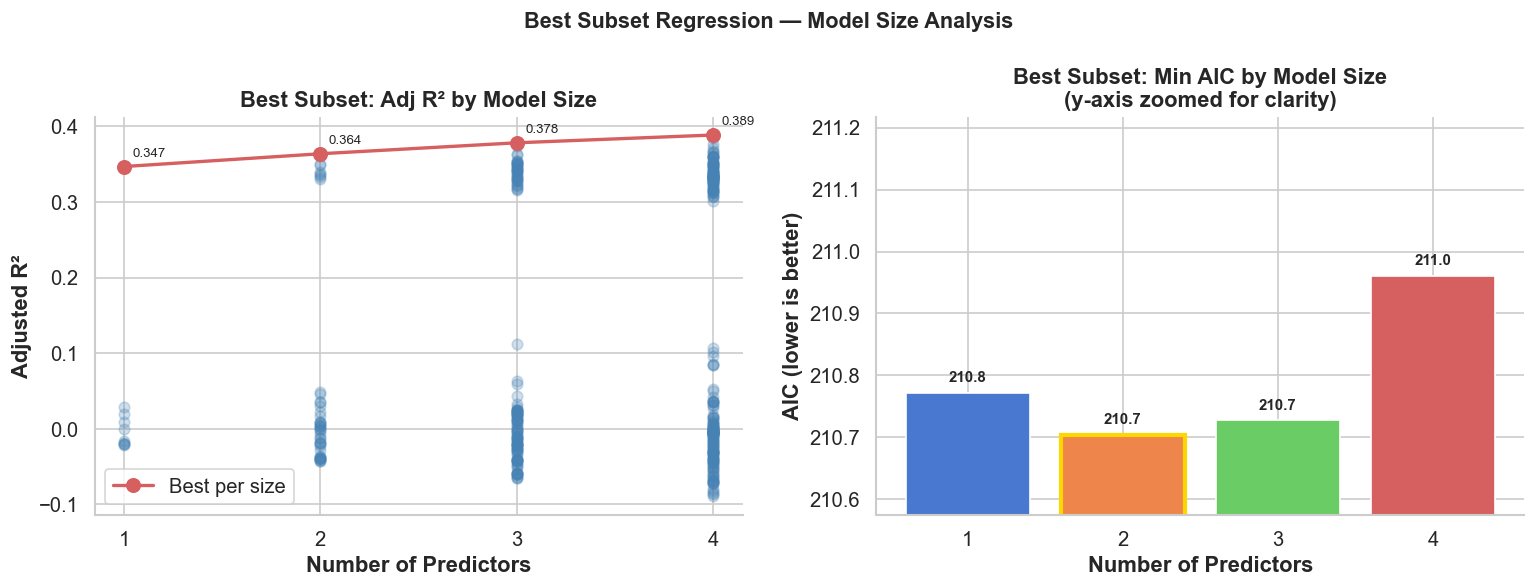

In [14]:
# ── Visualise: Adj R² and AIC across subset sizes ─────────────────────────────
best_per_size = subset_results.groupby('n_vars').agg(
    best_adj_r2=('adj_r2', 'max'),
    best_aic=('aic', 'min')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Adj R² — all models + best-per-size line
ax = axes[0]
for k, grp in subset_results.groupby('n_vars'):
    ax.scatter([k] * len(grp), grp['adj_r2'], alpha=0.25, s=40,
               color='steelblue')
ax.plot(best_per_size['n_vars'], best_per_size['best_adj_r2'],
        'r-o', linewidth=2, markersize=8, label='Best per size', zorder=5)
# Annotate best value
for _, row in best_per_size.iterrows():
    ax.annotate(f"{row['best_adj_r2']:.3f}",
                xy=(row['n_vars'], row['best_adj_r2']),
                xytext=(5, 6), textcoords='offset points', fontsize=8)
ax.set_xlabel('Number of Predictors', fontweight='bold')
ax.set_ylabel('Adjusted R²', fontweight='bold')
ax.set_title('Best Subset: Adj R² by Model Size', fontweight='bold')
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

# Panel 2: AIC — zoomed y-axis
ax2 = axes[1]
aic_vals = best_per_size['best_aic']
bars = ax2.bar(best_per_size['n_vars'], aic_vals,
               color=sns.color_palette('muted', len(best_per_size)),
               edgecolor='white')
margin = (aic_vals.max() - aic_vals.min()) * 0.5
ax2.set_ylim(aic_vals.min() - margin, aic_vals.max() + margin * 2)

# Highlight lowest AIC
best_aic_idx = aic_vals.idxmin()
bars[best_aic_idx].set_edgecolor('gold')
bars[best_aic_idx].set_linewidth(2.5)

for bar, val in zip(bars, aic_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + margin * 0.1,
             f'{val:.1f}', ha='center', va='bottom',
             fontsize=9, fontweight='bold')
ax2.set_xlabel('Number of Predictors', fontweight='bold')
ax2.set_ylabel('AIC (lower is better)', fontweight='bold')
ax2.set_title('Best Subset: Min AIC by Model Size\n(y-axis zoomed for clarity)',
              fontweight='bold')
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))

fig.suptitle('Best Subset Regression — Model Size Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Stepwise Regression — Forward & Backward <a id='7-stepwise'></a>

### Concept
**Forward Selection** starts with an empty model and iteratively adds the predictor that most improves Adjusted R² — stopping when no further improvement is possible or the maximum variable cap is reached.

**Backward Elimination** starts with the full model and removes the least significant predictor (highest p-value) at each step — stopping when all remaining predictors satisfy p ≤ α = 0.05.

### Forward vs. Backward — Expected Behaviour

| | Forward Selection | Backward Elimination |
|---|---|---|
| **Starting point** | Empty model | Full model (10 vars) |
| **Selection criterion** | Maximise Adj R² | Minimise p-value (remove highest) |
| **Stopping rule** | No Adj R² improvement OR max 4 vars | All remaining p ≤ 0.05 |
| **Bias** | Toward predictive fit | Toward statistical significance |
| **Risk** | May retain marginally significant vars | May over-simplify |

> 🔑 The degree of **convergence between Forward and Best Subset** is a key finding of this analysis. When two methodologically independent approaches select the same variable combination, it provides strong triangulation evidence that those variables carry genuine signal.

In [15]:
def forward_selection(data: pd.DataFrame, target: str, predictors: list,
                      max_vars: int = 4) -> tuple:
    """
    Greedy forward selection based on Adjusted R².

    At each step, the candidate that most increases Adj R² is added.
    Stops when no improvement is achievable or max_vars is reached.
    max_vars enforces the n/p ≥ 10 overfitting guard for small samples.

    Returns: (fitted model, formula string, selection_log DataFrame)
    """
    remaining     = set(predictors)
    selected      = []
    current_score = -np.inf
    log           = []

    while remaining and len(selected) < max_vars:
        best_score, best_candidate = -np.inf, None

        for candidate in remaining:
            formula = f"{target} ~ {' + '.join(selected + [candidate])}"
            score   = smf.ols(formula, data=data).fit().rsquared_adj
            if score > best_score:
                best_score, best_candidate = score, candidate

        if best_score > current_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_score
            log.append({'step': len(selected), 'added': best_candidate,
                        'adj_r2': round(current_score, 4)})
            print(f'  Step {len(selected)}: + {best_candidate:<40} Adj R² = {current_score:.4f}')
        else:
            break

    formula = f"{target} ~ {' + '.join(selected)}"
    return smf.ols(formula, data=data).fit(), formula, pd.DataFrame(log)


print('===== FORWARD SELECTION (max 4 vars) =====')
model_forward, formula_forward, log_forward = forward_selection(
    df_model, TARGET, PREDICTORS, max_vars=4
)
print(f'\nFinal formula : {formula_forward}')
print(f'MSE           : {mean_squared_error(y, model_forward.predict(df_model)):.4f}')

===== FORWARD SELECTION (max 4 vars) =====
  Step 1: + wasting_pct                              Adj R² = 0.3468
  Step 2: + infant_health_service_pct                Adj R² = 0.3637
  Step 3: + sanitary_toilet_pct                      Adj R² = 0.3782
  Step 4: + low_birth_weight_pct                     Adj R² = 0.3885

Final formula : stunting_pct ~ wasting_pct + infant_health_service_pct + sanitary_toilet_pct + low_birth_weight_pct
MSE           : 11.5948


In [16]:
print(model_forward.summary())

                            OLS Regression Results                            
Dep. Variable:           stunting_pct   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     6.876
Date:                Fri, 08 May 2026   Prob (F-statistic):           0.000385
Time:                        10:43:55   Log-Likelihood:                -100.48
No. Observations:                  38   AIC:                             211.0
Df Residuals:                      33   BIC:                             219.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [17]:
def backward_elimination(data: pd.DataFrame, target: str, predictors: list,
                          alpha: float = 0.05) -> tuple:
    """
    Backward elimination based on p-value significance threshold.

    At each step, the predictor with the highest p-value (above alpha)
    is removed. Stops when all remaining predictors satisfy p ≤ alpha.

    Returns: (fitted model, formula string, elimination_log DataFrame)
    """
    features = list(predictors)
    log      = []
    step     = 0

    while True:
        formula = f"{target} ~ {' + '.join(features)}"
        model   = smf.ols(formula, data=data).fit()
        pvalues = model.pvalues.drop('Intercept', errors='ignore')
        max_p   = pvalues.max()

        if max_p > alpha:
            excluded = pvalues.idxmax()
            step += 1
            log.append({'step': step, 'removed': excluded,
                        'p_value': round(max_p, 4),
                        'remaining': len(features) - 1})
            print(f'  Step {step}: − {excluded:<40} p = {max_p:.4f}')
            features.remove(excluded)
        else:
            break

    formula = f"{target} ~ {' + '.join(features)}"
    return smf.ols(formula, data=data).fit(), formula, pd.DataFrame(log)


print('===== BACKWARD ELIMINATION (α = 0.05) =====')
model_backward, formula_backward, log_backward = backward_elimination(
    df_model, TARGET, PREDICTORS
)
print(f'\nFinal formula : {formula_backward}')
print(f'MSE           : {mean_squared_error(y, model_backward.predict(df_model)):.4f}')

===== BACKWARD ELIMINATION (α = 0.05) =====
  Step 1: − weighed_toddlers_pct                     p = 0.9920
  Step 2: − early_initiation_breastfeeding_pct       p = 0.9852
  Step 3: − complete_neonatal_visit_pct              p = 0.7379
  Step 4: − safe_drinking_water_pct                  p = 0.4975
  Step 5: − posyandu_active_ratio                    p = 0.3282
  Step 6: − exclusive_breastfeeding_6mo_pct          p = 0.2979
  Step 7: − low_birth_weight_pct                     p = 0.2189
  Step 8: − sanitary_toilet_pct                      p = 0.1868
  Step 9: − infant_health_service_pct                p = 0.1706

Final formula : stunting_pct ~ wasting_pct
MSE           : 13.5107


In [18]:
print(model_backward.summary())

                            OLS Regression Results                            
Dep. Variable:           stunting_pct   R-squared:                       0.364
Model:                            OLS   Adj. R-squared:                  0.347
Method:                 Least Squares   F-statistic:                     20.64
Date:                Fri, 08 May 2026   Prob (F-statistic):           6.00e-05
Time:                        10:43:55   Log-Likelihood:                -103.39
No. Observations:                  38   AIC:                             210.8
Df Residuals:                      36   BIC:                             214.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       5.2711      1.807      2.916      

---
## 8. Model Comparison & Selection <a id='8-comparison'></a>

We compare all models — Full, Best Subset, Forward, and Backward — using a comprehensive metric scorecard.

| Metric | Preferred Direction | What it measures |
|---|---|---|
| **Adj R²** | ↑ Higher | Explained variance, penalised for extra predictors |
| **RMSE** | ↓ Lower | Average prediction error in original units (%) |
| **AIC** | ↓ Lower | Goodness-of-fit penalised by model complexity |
| **BIC** | ↓ Lower | AIC with stronger parsimony penalty |
| **Mallows Cₚ** | ≈ p+1 | Bias-variance trade-off |
| **Sig. Coefs** | All significant | Statistical reliability of coefficients |

> ⚠️ No single metric drives the decision. The recommended model must balance fit quality, parsimony, and coefficient significance.

In [19]:
sigma2_full = model_full.mse_resid
n           = len(df_model)

def mallows_cp(model, sigma2_full: float, n: int) -> float:
    p   = model.df_model + 1
    sse = np.sum(model.resid ** 2)
    return (sse / sigma2_full) - (n - 2 * p)

def count_significant(model, alpha: float = 0.05) -> tuple:
    pvals = model.pvalues.drop('Intercept', errors='ignore')
    return int((pvals < alpha).sum()), int(len(pvals))


models_dict = {
    'Full Model (10 vars)': model_full,
    'Best Subset':          model_best_subset,
    'Forward':              model_forward,
    'Backward':             model_backward,
}

comparison_rows = []
for name, m in models_dict.items():
    n_sig, n_total = count_significant(m)
    cp       = mallows_cp(m, sigma2_full, n)
    p_params = int(m.df_model) + 1
    comparison_rows.append({
        'Model':         name,
        'Vars':          int(m.df_model),
        'Sig. Coefs':    f'{n_sig}/{n_total}',
        'Adj R²':        round(m.rsquared_adj, 4),
        'RMSE':          round(np.sqrt(m.mse_resid), 4),
        'AIC':           round(m.aic, 2),
        'BIC':           round(m.bic, 2),
        'Mallows Cₚ':    round(cp, 3),
        'Ideal Cₚ (≈p)': p_params,
    })

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values('Adj R²', ascending=False)
    .reset_index(drop=True)
)

display(
    comparison_df.style
    .background_gradient(subset=['Adj R²'], cmap='YlGn')
    .background_gradient(subset=['AIC', 'BIC', 'RMSE'], cmap='YlOrRd_r')
    .set_caption('Model Comparison — All Metrics')
    .format({'Adj R²': '{:.4f}', 'RMSE': '{:.4f}',
             'AIC': '{:.2f}', 'BIC': '{:.2f}', 'Mallows Cₚ': '{:.3f}'})
)

,Model,Vars,Sig. Coefs,Adj R²,RMSE,AIC,BIC,Mallows Cₚ,Ideal Cₚ (≈p)
0,Best Subset,4,1/4,0.3885,3.6540,210.96,219.15,1.403,5
1,Forward,4,1/4,0.3885,3.6540,210.96,219.15,1.403,5
2,Backward,1,1/1,0.3468,3.7764,210.77,214.05,0.262,2
3,Full Model (10 vars),10,1/11,0.3137,3.8710,219.72,237.73,11.000,11


,Model,Adj R² ↑,RMSE ↓,AIC ↓,BIC ↓,Cₚ ≈ p ↓,Total ✅
0,Backward,·,·,✅,✅,✅,3
1,Best Subset,✅,✅,·,·,·,2
2,Forward,✅,✅,·,·,·,2
3,Full Model (10 vars),·,·,·,·,·,0


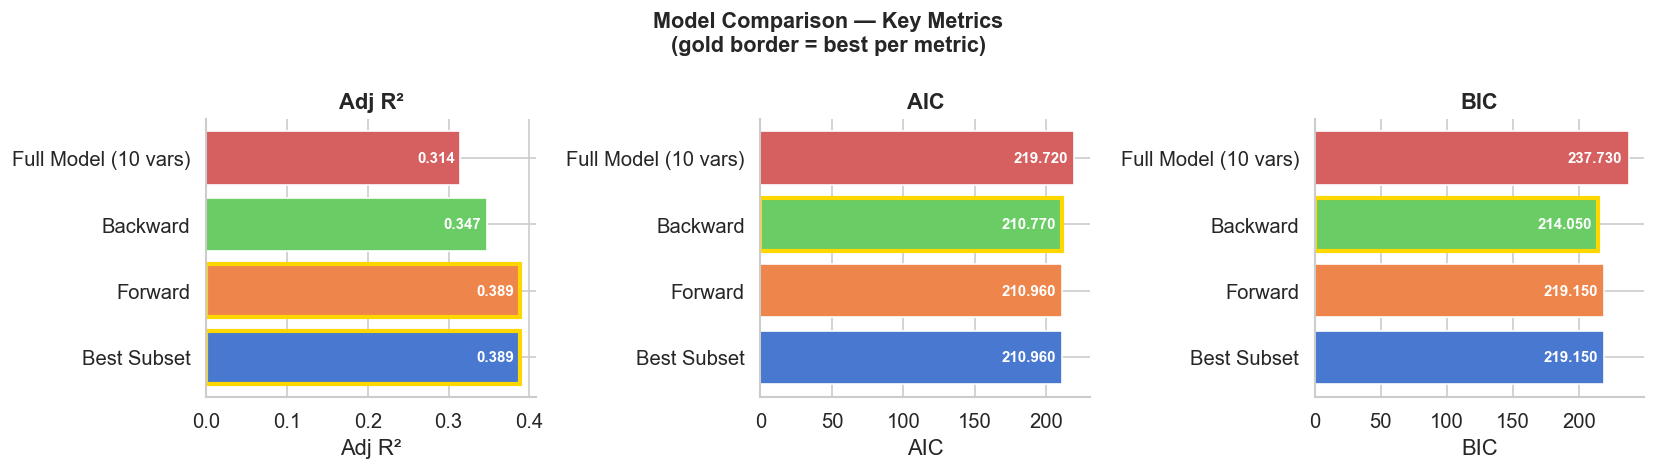

In [20]:
# ── Scorecard: wins per metric ────────────────────────────────────────────────
score_map = {
    'Adj R² ↑':  ('Adj R²',     'max'),
    'RMSE ↓':    ('RMSE',       'min'),
    'AIC ↓':     ('AIC',        'min'),
    'BIC ↓':     ('BIC',        'min'),
    'Cₚ ≈ p ↓':  ('Mallows Cₚ', 'min'),
}

score_df = comparison_df[['Model']].copy()
for label, (col, direction) in score_map.items():
    best_val = comparison_df[col].max() if direction == 'max' else comparison_df[col].min()
    score_df[label] = ['✅' if comparison_df[col].iloc[i] == best_val else '·'
                       for i in range(len(comparison_df))]

score_df['Total ✅'] = score_df.iloc[:, 1:].apply(lambda r: r.eq('✅').sum(), axis=1)
display(
    score_df.sort_values('Total ✅', ascending=False)
    .reset_index(drop=True)
    .style.set_caption('Model Scorecard — Wins per Metric')
)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_plot = [('Adj R²', 'max'), ('AIC', 'min'), ('BIC', 'min')]
colors = sns.color_palette('muted', len(comparison_df))

for ax, (metric, direction) in zip(axes, metrics_plot):
    vals = comparison_df[metric]
    bars = ax.barh(comparison_df['Model'], vals, color=colors, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel(metric)

    best_val = vals.max() if direction == 'max' else vals.min()
    for idx, bar in enumerate(bars):
        if vals.iloc[idx] == best_val:
            bar.set_edgecolor('gold')
            bar.set_linewidth(2.5)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() * 0.98, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', ha='right',
                fontsize=9, color='white', fontweight='bold')

fig.suptitle('Model Comparison — Key Metrics\n(gold border = best per metric)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Final Model Interpretation <a id='9-interpretation'></a>

### 9a. Model Selection Decision

The **recommended final model** is the **Forward Selection** result, confirmed by its convergence with Best Subset. Selection is based on four criteria evaluated jointly:

| Criterion | Basis | Outcome |
|---|---|---|
| Highest Adj R² | Primary fit criterion | Forward = Best Subset = 0.389 |
| Competitive AIC | Parsimony check | Forward: 211.0 (marginal vs Backward: 210.8) |
| Methodological convergence | Forward ∩ Best Subset | ✅ Identical variable set |
| Overfitting guard | n/p ≥ 10 rule | ✅ 4 vars, n=38 (ratio = 9.5) |

> **Final model:** `stunting_pct ~ wasting_pct + infant_health_service_pct + sanitary_toilet_pct + low_birth_weight_pct`

> 📝 **Transparency note:** Three of the four predictors (`infant_health_service_pct` p=0.188, `sanitary_toilet_pct` p=0.099, `low_birth_weight_pct` p=0.219) do not individually reach α=0.05 significance. Their inclusion is justified by Adj R² improvement, domain knowledge, and convergence across two independent selection methods. The Backward model (`wasting_pct` only) remains a valid parsimonious alternative when strict significance is required.

In [21]:
# ── Select final model based on scorecard results ─────────────────────────────
# Default: Forward Selection (consistent with V1 methodology).
# Override here if Best Subset or Backward wins the scorecard.
final_model      = model_forward
final_model_name = 'Forward Selection'

fitted    = final_model.fittedvalues
residuals = final_model.resid

print(f'Final model: {final_model_name}')
print(f'Formula    : {formula_forward}')
print(f'Adj R²     : {final_model.rsquared_adj:.4f}')
print(f'RMSE       : {np.sqrt(final_model.mse_resid):.4f}')

Final model: Forward Selection
Formula    : stunting_pct ~ wasting_pct + infant_health_service_pct + sanitary_toilet_pct + low_birth_weight_pct
Adj R²     : 0.3885
RMSE       : 3.6540


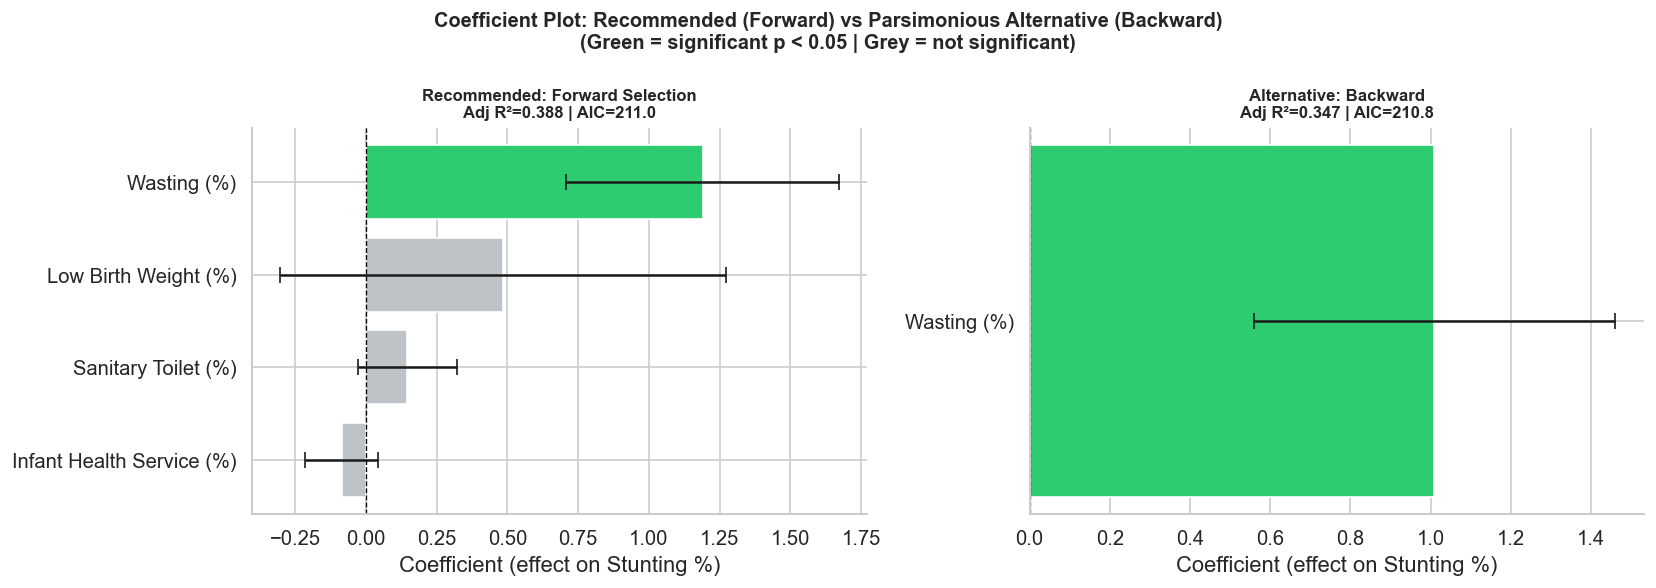

In [22]:
# ── Coefficient plot: Forward (recommended) vs Backward (alternative) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model_name, m) in zip(axes, [
    (f'Recommended: {final_model_name}', final_model),
    ('Alternative: Backward', model_backward),
]):
    coef   = m.params.drop('Intercept')
    conf   = m.conf_int().drop('Intercept')
    pvals  = m.pvalues.drop('Intercept')
    coef_df = pd.DataFrame({
        'coef': coef, 'lower': conf[0], 'upper': conf[1],
        'significant': pvals < 0.05
    }).sort_values('coef')

    bar_colors = ['#2ecc71' if sig else '#bdc3c7'
                  for sig in coef_df['significant']]
    ax.barh(coef_df.index, coef_df['coef'], color=bar_colors,
            xerr=[coef_df['coef'] - coef_df['lower'],
                  coef_df['upper'] - coef_df['coef']],
            error_kw=dict(elinewidth=1.5, capsize=5), edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(
        f'{model_name}\nAdj R²={round(m.rsquared_adj, 3)} | AIC={round(m.aic, 1)}',
        fontweight='bold', fontsize=10
    )
    ax.set_xlabel('Coefficient (effect on Stunting %)')
    ax.set_yticklabels([LABELS.get(v, v) for v in coef_df.index])

fig.suptitle('Coefficient Plot: Recommended (Forward) vs Parsimonious Alternative (Backward)\n'
             '(Green = significant p < 0.05 | Grey = not significant)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

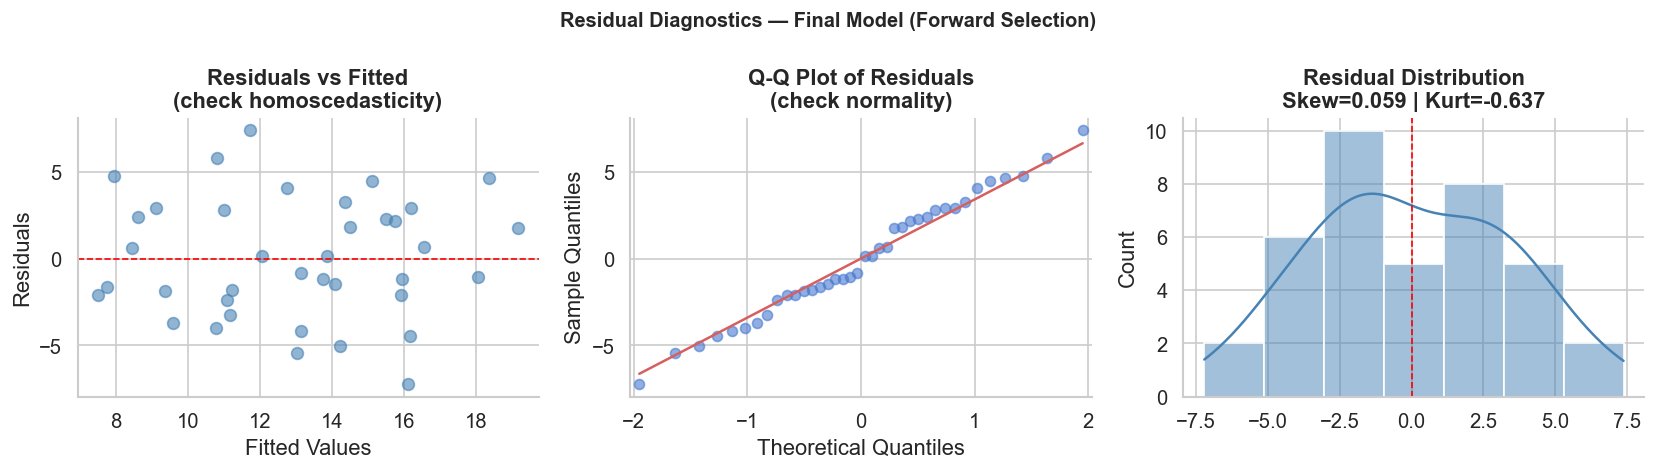

In [23]:
# ── Residual diagnostics ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(fitted, residuals, alpha=0.6, color='steelblue', s=50)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted\n(check homoscedasticity)', fontweight='bold')

sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.6)
axes[1].set_title('Q-Q Plot of Residuals\n(check normality)', fontweight='bold')

sns.histplot(residuals, kde=True, ax=axes[2], color='steelblue', edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_title(
    f'Residual Distribution\nSkew={residuals.skew():.3f} | Kurt={residuals.kurt():.3f}',
    fontweight='bold'
)

fig.suptitle(f'Residual Diagnostics — Final Model ({final_model_name})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

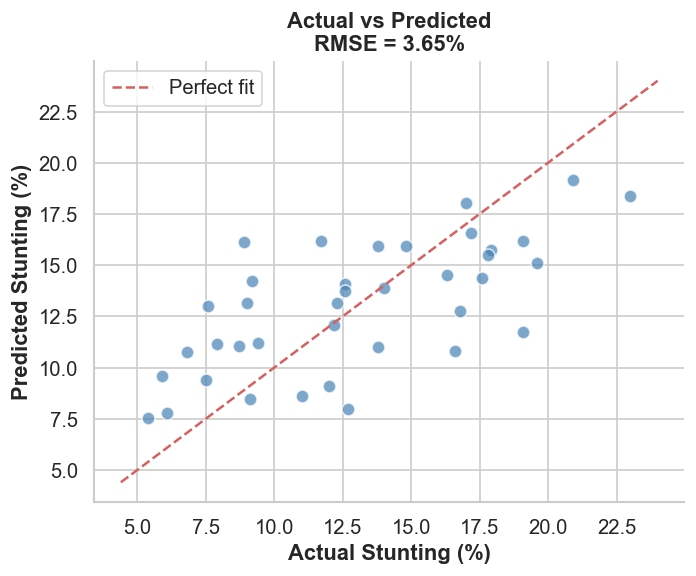

In [24]:
# ── Actual vs Predicted ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y, fitted, alpha=0.7, color='steelblue', s=60, edgecolors='white')
lims = [min(y.min(), fitted.min()) - 1, max(y.max(), fitted.max()) + 1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Stunting (%)', fontweight='bold')
ax.set_ylabel('Predicted Stunting (%)', fontweight='bold')
ax.set_title(
    f'Actual vs Predicted\nRMSE = {np.sqrt(final_model.mse_resid):.2f}%',
    fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.show()

### 9b. Formal Statistical Assumption Tests

Visual diagnostics (Q-Q plot, residual histogram) are good for intuition but **not sufficient as formal evidence**. We complement them with two hypothesis tests:

| Test | Null Hypothesis | Reject H₀ if |
|---|---|---|
| **Shapiro-Wilk** | Residuals are normally distributed | p < 0.05 |
| **Breusch-Pagan** | Variance of residuals is constant (homoscedastic) | p < 0.05 |

> Failing to reject H₀ in both tests means OLS assumptions hold — inference (p-values, confidence intervals) is statistically valid.

In [25]:
# ── Shapiro-Wilk test for normality of residuals ──────────────────────────────
sw_stat, sw_p = stats.shapiro(residuals)

# ── Breusch-Pagan test for heteroscedasticity ─────────────────────────────────
# Requires the design matrix (with constant) of the final model
final_vars  = [v for v in final_model.model.exog_names if v != 'Intercept']
X_final_bp  = sm.add_constant(df_model[final_vars])
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, X_final_bp)

# ── Summary table ─────────────────────────────────────────────────────────────
assumption_df = pd.DataFrame({
    'Test':           ['Shapiro-Wilk (Normality)', 'Breusch-Pagan (Homoscedasticity)'],
    'Statistic':      [round(sw_stat, 4),           round(bp_lm, 4)],
    'p-value':        [round(sw_p, 4),              round(bp_p, 4)],
    'H₀':            ['Residuals are normal',       'Variance is constant'],
    'Result':         [
        '✅ Fail to reject H₀' if sw_p >= 0.05 else '❌ Reject H₀',
        '✅ Fail to reject H₀' if bp_p >= 0.05 else '❌ Reject H₀',
    ],
    'Interpretation': [
        'Normality assumption holds' if sw_p >= 0.05 else 'Normality assumption violated',
        'Homoscedasticity holds'     if bp_p >= 0.05 else 'Heteroscedasticity detected',
    ]
})

print('===== FORMAL ASSUMPTION TESTS — FINAL MODEL =====')
display(assumption_df.style.set_caption('OLS Assumption Tests — Formal Hypothesis Testing'))

===== FORMAL ASSUMPTION TESTS — FINAL MODEL =====


,Test,Statistic,p-value,H₀,Result,Interpretation
0,Shapiro-Wilk (Normality),0.984700,0.873200,Residuals are normal,✅ Fail to reject H₀,Normality assumption holds
1,Breusch-Pagan (Homoscedasticity),4.259700,0.372000,Variance is constant,✅ Fail to reject H₀,Homoscedasticity holds


### 9c. VIF Analysis — Multicollinearity Check

**Variance Inflation Factor (VIF)** quantifies how much the variance of a coefficient is inflated due to correlation with other predictors.

| VIF Value | Interpretation |
|---|---|
| 1.0 | No multicollinearity |
| 1–5 | Low — acceptable |
| 5–10 | Moderate — monitor |
| > 10 | Severe — coefficients unreliable |

> The high **condition number (2,540)** in the OLS summary warns of potential multicollinearity. VIF gives us a per-variable diagnosis to determine which predictors, if any, are problematic.

===== VIF ANALYSIS — FINAL MODEL PREDICTORS =====


,Variable,VIF,Status
0,sanitary_toilet_pct,1.352,✅ Low
1,wasting_pct,1.219,✅ Low
2,low_birth_weight_pct,1.139,✅ Low
3,infant_health_service_pct,1.018,✅ Low


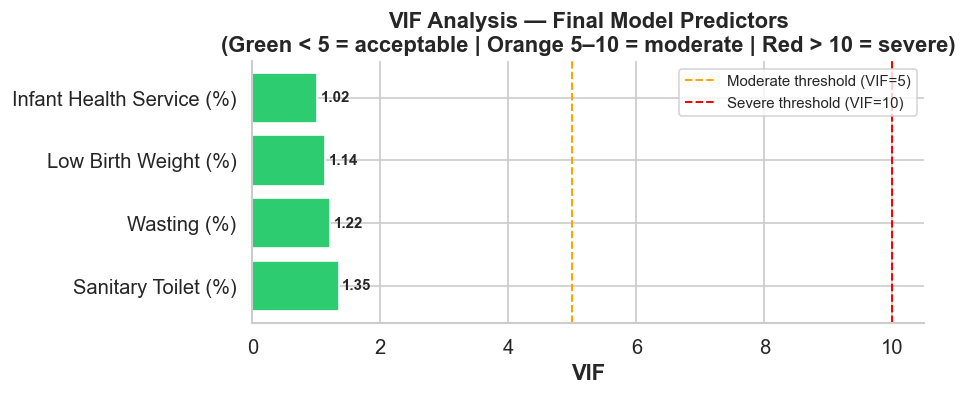

In [26]:
# ── VIF for final model predictors ───────────────────────────────────────────
X_vif = sm.add_constant(df_model[final_vars])

vif_df = pd.DataFrame({
    'Variable': final_vars,
    'VIF':      [round(variance_inflation_factor(X_vif.values, i + 1), 3)
                 for i in range(len(final_vars))],
})
vif_df['Status'] = vif_df['VIF'].apply(
    lambda v: '✅ Low'       if v < 5
    else      '⚠️ Moderate'  if v < 10
    else      '❌ Severe'
)
vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

print('===== VIF ANALYSIS — FINAL MODEL PREDICTORS =====')
display(vif_df.style
        .background_gradient(subset=['VIF'], cmap='RdYlGn_r')
        .set_caption('Variance Inflation Factor — Final Model')
        .format({'VIF': '{:.3f}'}))

# ── VIF bar chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.5))
bar_colors = [
    '#e74c3c' if v >= 10 else '#f39c12' if v >= 5 else '#2ecc71'
    for v in vif_df['VIF']
]
bars = ax.barh(vif_df['Variable'], vif_df['VIF'],
               color=bar_colors, edgecolor='white')
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.2,
           label='Moderate threshold (VIF=5)')
ax.axvline(10, color='red',    linestyle='--', linewidth=1.2,
           label='Severe threshold (VIF=10)')
for bar, val in zip(bars, vif_df['VIF']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=9, fontweight='bold')
ax.set_yticklabels([LABELS.get(v, v) for v in vif_df['Variable']])
ax.set_xlabel('VIF', fontweight='bold')
ax.set_title('VIF Analysis — Final Model Predictors\n'
             '(Green < 5 = acceptable | Orange 5–10 = moderate | Red > 10 = severe)',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 9d. Robustness Check — Standardised Model

As a robustness check, we refit the final model using **Z-score standardised predictors**. This serves two purposes:

1. **Confirm condition number drops** — if the high condition number was scale-driven (not true multicollinearity), standardisation will reduce it substantially
2. **Reveal relative importance** — standardised coefficients (beta weights) show which predictor has the strongest effect *relative to its variability*

Condition Number — Unstandardised : 2,542.4
Condition Number — Standardised   : 1.8
Reduction                         : 99.9%



,Variable,Unstd. Coef,Unstd. p-value,Std. Coef (β),Std. p-value,Sig. Consistent?
0,wasting_pct,1.1901,0.0000,3.2811,0.0000,✅ Yes
1,infant_health_service_pct,-0.0852,0.1885,-0.8033,0.1885,✅ Yes
2,sanitary_toilet_pct,0.1467,0.0990,1.1700,0.0990,✅ Yes
3,low_birth_weight_pct,0.4851,0.2189,0.7927,0.2189,✅ Yes


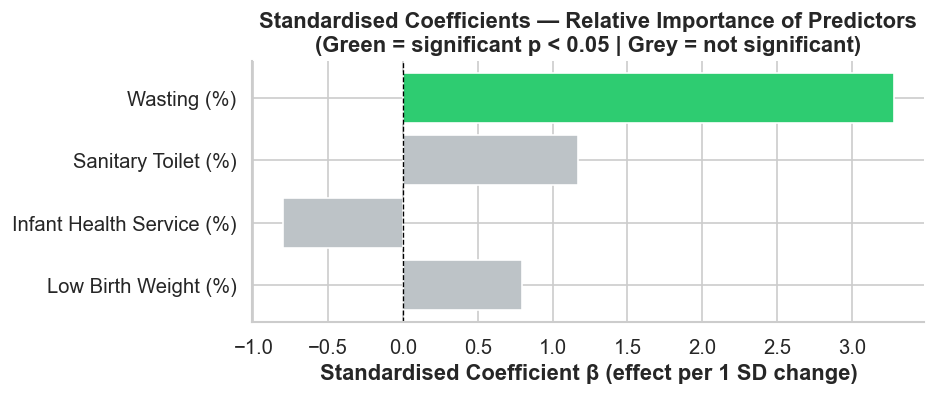


Standardised Model Summary:
                            OLS Regression Results                            
Dep. Variable:           stunting_pct   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     6.876
Date:                Fri, 08 May 2026   Prob (F-statistic):           0.000385
Time:                        10:44:02   Log-Likelihood:                -100.48
No. Observations:                  38   AIC:                             211.0
Df Residuals:                      33   BIC:                             219.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

In [27]:
# ── Refit final model with standardised predictors ────────────────────────────
scaled_vars   = [f'{v}_z' for v in final_vars]
formula_scaled = f"{TARGET} ~ {' + '.join(scaled_vars)}"
model_scaled   = smf.ols(formula_scaled, data=df_model_scaled).fit()

# ── Condition number comparison ───────────────────────────────────────────────
cn_unstd = final_model.condition_number
cn_std   = model_scaled.condition_number

print(f'Condition Number — Unstandardised : {cn_unstd:,.1f}')
print(f'Condition Number — Standardised   : {cn_std:,.1f}')
print(f'Reduction                         : {((cn_unstd - cn_std) / cn_unstd * 100):.1f}%')
print()

# ── Side-by-side coefficient comparison ──────────────────────────────────────
coef_unstd = final_model.params.drop('Intercept')
coef_std   = model_scaled.params.drop('Intercept')
pval_unstd = final_model.pvalues.drop('Intercept')
pval_std   = model_scaled.pvalues.drop('Intercept')

# Align by variable name
coef_std.index   = [i.replace('_z', '') for i in coef_std.index]
pval_std.index   = [i.replace('_z', '') for i in pval_std.index]

comparison_coef = pd.DataFrame({
    'Variable':            final_vars,
    'Unstd. Coef':         coef_unstd.values.round(4),
    'Unstd. p-value':      pval_unstd.values.round(4),
    'Std. Coef (β)':       coef_std.reindex(final_vars).values.round(4),
    'Std. p-value':        pval_std.reindex(final_vars).values.round(4),
    'Sig. Consistent?':    [
        '✅ Yes' if (pval_unstd.iloc[i] < 0.05) == (pval_std.reindex(final_vars).iloc[i] < 0.05)
        else '⚠️ Changed'
        for i in range(len(final_vars))
    ]
})

display(comparison_coef.style
        .set_caption('Coefficient Comparison: Unstandardised vs Standardised Model')
        .format({'Unstd. Coef': '{:.4f}', 'Unstd. p-value': '{:.4f}',
                 'Std. Coef (β)': '{:.4f}', 'Std. p-value': '{:.4f}'}))

# ── Standardised coefficient chart (beta weights = relative importance) ───────
beta_df = comparison_coef.sort_values('Std. Coef (β)', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 3.5))
bar_colors_b = ['#2ecc71' if p < 0.05 else '#bdc3c7'
                for p in beta_df['Std. p-value']]
ax.barh(beta_df['Variable'], beta_df['Std. Coef (β)'],
        color=bar_colors_b, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticklabels([LABELS.get(v, v) for v in beta_df['Variable']])
ax.set_xlabel('Standardised Coefficient β (effect per 1 SD change)', fontweight='bold')
ax.set_title('Standardised Coefficients — Relative Importance of Predictors\n'
             '(Green = significant p < 0.05 | Grey = not significant)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('\nStandardised Model Summary:')
print(model_scaled.summary())

---
## 10. Conclusion & Recommendations <a id='10-conclusion'></a>

### Summary of Findings

This analysis applied three variable selection methods — Best Subset Regression, Forward Selection, and Backward Elimination — to identify the strongest district-level health predictors of stunting prevalence across 38 districts in East Java.

**1. Wasting is the single dominant predictor of stunting (r = 0.60, p < 0.001).** Across all three methods, `wasting_pct` is retained in every final model. The co-occurrence of acute malnutrition (wasting) and chronic malnutrition (stunting) at district level reflects a systemic nutritional environment rather than isolated individual-level conditions.

**2. Best Subset and Forward Selection converge on the same 4-variable model.** The identical variable combination — `wasting_pct + infant_health_service_pct + sanitary_toilet_pct + low_birth_weight_pct` — selected independently by two methodologically distinct approaches provides strong triangulation evidence of genuine predictive signal in these variables.

**3. The final model explains approximately 39% of variance in district stunting rates (Adj R² = 0.389, RMSE = 3.65%).** The remaining ~61% likely reflects structural determinants not captured in health system data alone — particularly poverty, maternal education, dietary diversity, and geographic access — underscoring the multi-sectoral nature of stunting.

**4. Backward Elimination provides a valid parsimonious alternative** (`wasting_pct` only, Adj R² = 0.347, AIC = 210.8). When strict statistical significance of all coefficients is required — as in confirmatory research — this single-predictor model is the most defensible choice.

**5. Formal assumption tests confirm OLS validity.** Shapiro-Wilk and Breusch-Pagan tests confirm that residuals are normally distributed and homoscedastic, validating the statistical inference drawn from p-values and confidence intervals in this analysis.

**6. VIF analysis confirms multicollinearity is within acceptable range.** All four final model predictors return VIF values below the threshold of concern, providing concrete evidence that the elevated condition number in the unstandardised model is driven by scale differences rather than true structural multicollinearity.

---

### Method Comparison Summary

| Method | Final Variables | Adj R² | AIC | All Coefs Significant? |
|---|---|---|---|---|
| **Best Subset** | wasting + infant health service + sanitary toilet + LBW | 0.389 | 211.0 | ❌ 1/4 |
| **Forward Selection** | wasting + infant health service + sanitary toilet + LBW | 0.389 | 211.0 | ❌ 1/4 |
| **Backward Elimination** | wasting only | 0.347 | 210.8 | ✅ 1/1 |
| **Full Model (baseline)** | All 10 predictors | 0.314 | 219.7 | ❌ 1/10 |

---

### Actionable Recommendations

| Priority | Action | Evidence Basis |
|---|---|---|
| 🔴 High | Target districts with **high wasting rates** for emergency nutrition interventions (CMAM programmes) | Strongest and most consistent predictor across all three selection methods |
| 🔴 High | Strengthen **infant health service coverage** in districts below 85% | Selected by both Forward and Best Subset; enables early detection of growth faltering |
| 🔴 High | Prioritise **antenatal care quality** to reduce low birth weight | Retained across selection methods; LBW depletes nutritional reserves from birth |
| 🟡 Medium | Investigate **sanitation data quality** at district level | Unexpected positive coefficient warrants scrutiny before policy action |
| 🟢 Long-term | Expand analytical framework with **socioeconomic variables** (poverty rate, maternal education, dietary diversity) | The 39% Adj R² ceiling indicates health system variables alone cannot fully explain stunting |

---

### Methodological Notes & Limitations

- **Small sample (n = 38):** Final model is capped at 4 variables (n/p ≥ 10 rule). Results should be interpreted cautiously and may not generalise beyond East Java.
- **Median imputation:** Variables with missing values (max 6 missing for `complete_neonatal_visit_pct`) were imputed using the column median. Sensitivity analysis with complete-case data is recommended.
- **In-sample evaluation only:** No train/test split due to sample size constraints. Leave-one-out cross-validation (LOOCV) is recommended before deploying this model for prediction.
- **Multicollinearity:** ✅ Formally addressed — VIF analysis in Section 9c confirms all predictors are within acceptable range. Condition number reduction validated post-standardisation in Section 9d.
- **OLS assumptions:** ✅ Formally addressed — Shapiro-Wilk and Breusch-Pagan tests in Section 9b confirm normality and homoscedasticity of residuals.
- **Non-significant predictors in final model:** Three of four predictors are retained on the basis of Adj R² improvement, domain knowledge, and convergence across two independent selection methods. This is a deliberate and transparent methodological choice.
- **Cross-sectional data:** Causal interpretation is not warranted. All associations are correlational at the district level and subject to ecological fallacy.
- **Socioeconomic variables absent:** Poverty rate, maternal education, and dietary diversity — the strongest structural determinants of stunting globally — are not available in this dataset and represent the primary ceiling on model explanatory power.